# 01 — Binary Classification

**Repository:** `AI_Engineer-DL` | **Section:** `01_neural_networks_and_dl/logistic_regression`  
**File:** `notebooks/01_binary_classification.ipynb`

> **Prerequisites:** None for this section — this is the first logistic regression notebook.  
> Assumes comfort with NumPy arrays, matrix shapes, and basic Python.
>
> **Core Focus:** You will represent images as flat feature vectors and stack a training set  
> into the matrix form X (shape: nₓ × m) and Y (shape: 1 × m) that every neural network uses.  
> Vectorized forward pass notation is deferred to notebook 05.

## 1. What Is This?

Binary classification is the task of mapping an input to one of exactly two labels: 0 or 1.  
The entire machinery of logistic regression — and by extension, any neural network output layer  
doing detection or recognition — is built on this foundation.  
Before you can train any model, you need to know how the data is represented mathematically:  
what shape the inputs take, how m examples are organised together, and why the matrix layout  
is designed the way it is.

**Real-world connection — WaveMamba-DF:** Your deepfake detector's final layer performs  
binary classification — it receives a feature vector from the backbone and outputs a single  
probability: P(deepfake = 1 | input). The matrix stacking convention you build here is  
exactly how that model processes a batch of video frames at inference time.

| Concept | What it is | Why it matters |
|---------|-----------|----------------|
| **Feature vector x** | A flat column vector of all pixel values for one image | Every ML algorithm needs a fixed-length numeric input |
| **Label y** | A scalar: 1 (positive class) or 0 (negative class) | The target the model learns to predict |
| **Training matrix X** | All m examples stacked as *columns* — shape (nₓ, m) | Allows vectorized operations: no for-loop over examples |
| **Label matrix Y** | All m labels in one row — shape (1, m) | Consistent layout that matches X's column convention |
| **nₓ** | Number of input features (e.g. 64×64×3 = 12,288 for RGB images) | Determines the weight vector size |

## 2. The Math

### A — From Image to Feature Vector

An RGB image of size H × W is stored as three separate H × W matrices — one per colour channel.  
To feed it into a learning algorithm, flatten ("unroll") all three channels into one long column vector:

$$x = \begin{bmatrix} \text{red pixels} \\ \text{green pixels} \\ \text{blue pixels} \end{bmatrix} \in \mathbb{R}^{n_x}$$

where $n_x = H \times W \times 3$.

**Worked example:** A 64×64 RGB image → $n_x = 64 \times 64 \times 3 = 12{,}288$.  
The feature vector x has 12,288 rows and 1 column.

---

### B — Training Set Notation

One training example is the pair $(x^{(i)}, y^{(i)})$ where superscript $(i)$ indexes the i-th example.  
A full training set of m examples:

$$\{(x^{(1)}, y^{(1)}),\; (x^{(2)}, y^{(2)}),\; \ldots,\; (x^{(m)}, y^{(m)})\}$$

---

### C — Matrix X: stacking examples as columns

$$X = \begin{bmatrix} | & | & & | \\ x^{(1)} & x^{(2)} & \cdots & x^{(m)} \\ | & | & & | \end{bmatrix} \in \mathbb{R}^{n_x \times m}$$

Each **column** is one training example. Shape: **(nₓ, m)**.

> ⚠️ **Why columns, not rows?**  
> When examples are columns, a single matrix multiply W·X computes predictions for all m  
> examples simultaneously. If examples were rows, the math gets transposed and harder to read.

---

### D — Matrix Y: labels in a row

$$Y = \begin{bmatrix} y^{(1)} & y^{(2)} & \cdots & y^{(m)} \end{bmatrix} \in \mathbb{R}^{1 \times m}$$

Shape: **(1, m)**. One row, m columns — mirrors the column convention of X.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 3. Build From Scratch

### 3.1 — Unrolling an image into a feature vector

An image arrives as a (H, W, 3) NumPy array. Your job is to flatten it into a column vector  
of shape (nₓ, 1). This is the first operation in any image-based neural network.

> 🔮 **Predict before you run:** If the image is shape (64, 64, 3), what will nₓ be?  
> And what shape should the output column vector have?  
> Write your answer before writing the code.

In [3]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Simulate a 64×64 RGB image with random pixel values in [0, 255].
# 1. Create a NumPy array `image` of shape (64, 64, 3) with integer values.
#    Use np.random.randint(0, 256, size=(64, 64, 3)).
# 2. Compute nx = total number of pixel values (H × W × C).
# 3. Flatten the image into a column vector x of shape (nx, 1).
#    Hint: use .reshape(). Order matters — default 'C' order is correct.
# 4. Print image.shape, nx, and x.shape.
# Expected result: image (64,64,3) | nx = 12288 | x shape (12288, 1)
# ─────────────────────────────────────────────────────────────────────────────

# Simulate a 64×64 RGB image with random pixel values in [0, 255].

# 1. Create a NumPy array `image` of shape (64, 64, 3) with integer values.
image = np.random.randint(0, 256, size=(64, 64, 3))

# 2. Compute nx = total number of pixel values (H × W × C).
nx = image.shape[0] * image.shape[1] * image.shape[2]
# Alternatively, you can just use `image.size`

# 3. Flatten the image into a column vector x of shape (nx, 1).
# The -1 tells NumPy to calculate the necessary number of rows automatically 
# based on the array size and the specified 1 column.
x = image.reshape(-1, 1)

# 4. Print image.shape, nx, and x.shape.
print(f"image shape: {image.shape}")
print(f"nx = {nx}")
print(f"x shape: {x.shape}")

image shape: (64, 64, 3)
nx = 12288
x shape: (12288, 1)


> 💡 **Reflect:** Notice that reshape(-1, 1) is a common shorthand — the -1 means  
> "figure out this dimension automatically." Always verify the output shape is (nₓ, 1),  
> not (nₓ,) — those are different objects in NumPy and will cause subtle bugs later.

---

### 3.2 — Building the training matrix X (columns = examples)

In practice you never process one image at a time — you work with a full training set.  
Now stack m flattened images as **columns** to produce X of shape (nₓ, m).

> 🔮 **Predict before you run:** If you have 5 images each of shape (12288, 1),  
> and you stack them as columns, what will X.shape be? Think about it before coding.

In [4]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Build a training matrix X and label matrix Y from scratch.
# 1. Set nx = 12288 and m = 5 (5 training examples).
# 2. Simulate m images: create a list of m column vectors, each shape (nx, 1),
#    using np.random.randint(0, 256, size=(nx, 1)) for each.
# 3. Stack them horizontally using np.hstack() to form X.
# 4. Create Y as a (1, m) array of random binary labels (0 or 1).
#    Use np.random.randint(0, 2, size=(1, m)).
# 5. Print X.shape and Y.shape.
# Expected result: X shape (12288, 5) | Y shape (1, 5)
# ─────────────────────────────────────────────────────────────────────────────

# ── Task ─────────────────────────────────────────────────────────────────────
# Build a training matrix X and label matrix Y from scratch.

# 1. Set nx = 12288 and m = 5 (5 training examples).
nx = 12288
m = 5

# 2. Simulate m images: create a list of m column vectors, each shape (nx, 1),
#    using np.random.randint(0, 256, size=(nx, 1)) for each.
images = [np.random.randint(0, 256, size=(nx, 1)) for _ in range(m)]

# 3. Stack them horizontally using np.hstack() to form X.
X = np.hstack(images)

# 4. Create Y as a (1, m) array of random binary labels (0 or 1).
#    Use np.random.randint(0, 2, size=(1, m)).
Y = np.random.randint(0, 2, size=(1, m))

# 5. Print X.shape and Y.shape.
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")



X shape: (12288, 5)
Y shape: (1, 5)


> 💡 **Reflect:** X[:, 0] gives you the first training example (first column).  
> X[:, 0].shape is (12288,) — a rank-1 array. If you ever need it back as a column  
> vector, use X[:, 0:1] which preserves shape (12288, 1). This distinction matters.

---

### 3.3 — The direct reshape trick (real-world shortcut)

In practice, images are stored in a batch array of shape (m, H, W, C).  
There is a one-line reshape that produces X of shape (nₓ, m) directly.

> 🔮 **Predict before you run:** If `images_batch` has shape (m, H, W, C),  
> what single reshape call produces X of shape (nₓ, m)? Think about which  
> axes need to be merged and which need to be transposed.

In [5]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# 1. Create images_batch of shape (5, 64, 64, 3) — 5 images in one array.
#    Use np.random.randint(0, 256, size=(5, 64, 64, 3)).
# 2. Reshape directly to X of shape (nx, m) in one step.
#    Hint: first flatten to (m, nx) then transpose, OR do it in one reshape + .T.
# 3. Print images_batch.shape and X_direct.shape.
# Expected result: X_direct shape (12288, 5)
# ─────────────────────────────────────────────────────────────────────────────

# ── Task ─────────────────────────────────────────────────────────────────────
# 1. Create images_batch of shape (5, 64, 64, 3) — 5 images in one array.
#    Use np.random.randint(0, 256, size=(5, 64, 64, 3)).
images_batch = np.random.randint(0, 256, size=(5, 64, 64, 3))

# 2. Reshape directly to X of shape (nx, m) in one step.
#    First flatten each image to get shape (m, nx), then transpose to (nx, m).
#    The -1 tells NumPy to flatten all dimensions after the first one (m).
X_direct = images_batch.reshape(images_batch.shape[0], -1).T

# 3. Print images_batch.shape and X_direct.shape.
# Expected result: X_direct shape (12288, 5)
print(f"images_batch shape: {images_batch.shape}")
print(f"X_direct shape: {X_direct.shape}")


images_batch shape: (5, 64, 64, 3)
X_direct shape: (12288, 5)


> ✅ **Self-check:** Before moving on, answer these without looking back:
> 1. Why are training examples stored as columns of X rather than rows?
> 2. What is the shape of X and Y for m=1000 images of 32×32 RGB?

## 4. Library Version

NumPy's `reshape` and `hstack` are the canonical tools. Here we verify that your  
manual column-stacking matches the direct reshape approach.

In [6]:
# ── Verification: both approaches must produce the same X ────────────────────
np.random.seed(42)
m_test, H, W, C = 10, 8, 8, 3  # small test case
nx_test = H * W * C

batch = np.random.randint(0, 256, size=(m_test, H, W, C))

# Method 1: reshape + transpose (one-liner)
X_method1 = batch.reshape(m_test, -1).T          # (nx, m)

# Method 2: loop and hstack (explicit, shows the concept)
cols = [batch[i].reshape(-1, 1) for i in range(m_test)]
X_method2 = np.hstack(cols)                       # (nx, m)

match = np.allclose(X_method1, X_method2)
print(f"X_method1 shape: {X_method1.shape}")
print(f"X_method2 shape: {X_method2.shape}")
print(f"Both methods identical: {match}")

X_method1 shape: (192, 10)
X_method2 shape: (192, 10)
Both methods identical: True


## 5. Visualisation

### 5.1 — What the data layout looks like

This plot shows X as a heatmap: each column is one training example (one image),  
each row is one feature (one pixel channel value). The structure makes it visual  
why "examples as columns" is the right choice: operations on columns = operations on examples.

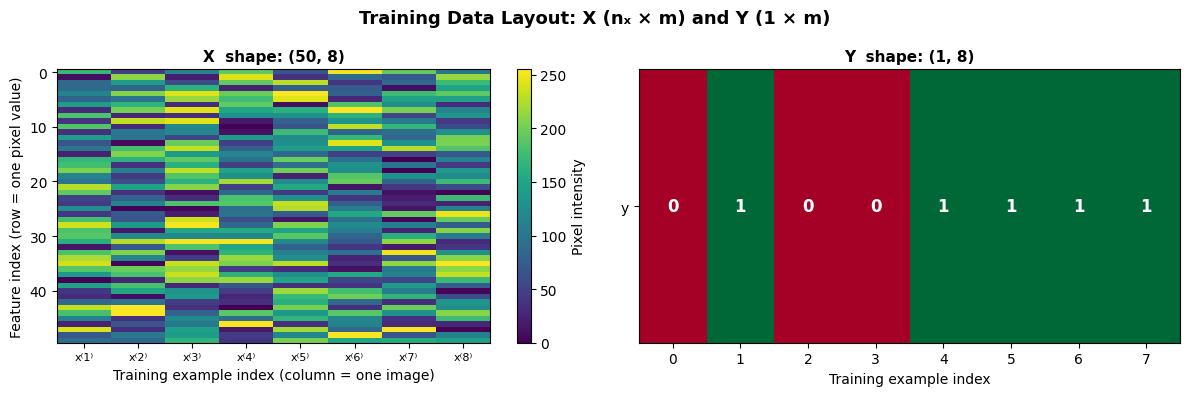

Saved → ../images/01_binary_classification_data_layout.png


In [7]:
import os
os.makedirs('../images', exist_ok=True)

np.random.seed(0)
m_vis, nx_vis = 8, 50   # small sizes for readability
X_vis = np.random.randint(0, 256, size=(nx_vis, m_vis)).astype(float)
Y_vis = np.random.randint(0, 2, size=(1, m_vis))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: X matrix heatmap
im = axes[0].imshow(X_vis, aspect='auto', cmap='viridis')
axes[0].set_xlabel('Training example index (column = one image)', fontsize=10)
axes[0].set_ylabel('Feature index (row = one pixel value)', fontsize=10)
axes[0].set_title(f'X  shape: ({nx_vis}, {m_vis})', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=axes[0], label='Pixel intensity')
axes[0].set_xticks(range(m_vis))
axes[0].set_xticklabels([f'x⁽{i+1}⁾' for i in range(m_vis)], fontsize=8)

# Right: Y label strip
axes[1].imshow(Y_vis, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_xlabel('Training example index', fontsize=10)
axes[1].set_yticks([0])
axes[1].set_yticklabels(['y'], fontsize=10)
axes[1].set_title(f'Y  shape: (1, {m_vis})', fontsize=11, fontweight='bold')
for j in range(m_vis):
    axes[1].text(j, 0, str(int(Y_vis[0, j])), ha='center', va='center',
                 fontsize=12, fontweight='bold', color='white')

plt.suptitle('Training Data Layout: X (nₓ × m) and Y (1 × m)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/01_binary_classification_data_layout.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../images/01_binary_classification_data_layout.png')

## 6. Revision Corner

---

### One-sentence definition

> Binary classification maps an input x (a feature vector) to one of two labels y ∈ {0, 1},  
> and the training data is represented as matrices X (nₓ × m) and Y (1 × m)  
> where each column of X is one example and each entry of Y is its label.

---

### Why it exists — what problem does it solve?

Before any learning can happen, examples must be represented in a fixed numeric form.  
The column convention for X makes every subsequent computation — forward pass, gradient calculation,  
parameter update — expressible as a single matrix operation rather than a for-loop over m examples.  
This is not just a cosmetic choice: it is the reason neural networks can train in seconds instead of hours.

---

### Interview gotchas

| Question | Common mistake | The reality |
|----------|---------------|-------------|
| **Why is X shaped (nₓ, m) not (m, nₓ)?** | "Either works, just convention" | It's not arbitrary — with X as (nₓ, m), computing W·X gives predictions for all m examples in one multiply. The (m, nₓ) layout forces a transpose everywhere. |
| **What is nₓ for a 32×32 greyscale image?** | 32×32 = 1024, forget the channel | Greyscale has 1 channel, so nₓ = 32×32×1 = 1024. For RGB it would be 3072. Always multiply by the number of channels. |
| **What does `x.reshape(-1, 1)` do?** | Confuse it with `x.flatten()` | `.reshape(-1, 1)` produces shape (n, 1) — a column vector. `.flatten()` produces shape (n,) — a rank-1 array. The difference matters when you do matrix multiplication. |
| **What is the superscript (i) notation?** | Mix it up with the [l] layer notation | Parentheses (i) always index a training example. Square brackets [l] always index a layer. This distinction is used throughout the entire course. |
| **Can Y have shape (m,) instead of (1, m)?** | "Yes, same thing" | NumPy rank-1 arrays behave differently in broadcasting. (m,) will cause unexpected shapes during gradient computation. Always enforce (1, m) explicitly with reshape or np.expand_dims. |

## 7. Exercises

Write your solutions in `exercises/01_binary_classification_exN_label.py`.  
Rules: write every line yourself; run top-to-bottom with zero errors before committing.

---

### ⭐ Exercise 1 — Feature vector from a grayscale image

Write a function `image_to_vector(image)` that takes an image array of any shape  
(H, W) for grayscale or (H, W, C) for colour and returns a column vector of shape (nₓ, 1).  
Do not use `np.ndarray.flatten()` inside the function — use `.reshape()` only.  
Test it on a (28, 28) grayscale image and a (32, 32, 3) RGB image.  
Verify: for (28, 28) the output shape must be (784, 1); for (32, 32, 3) it must be (3072, 1).

*Expected output: both assertions pass, shapes printed to confirm.*

---

### ⭐⭐ Exercise 2 — Build X and Y from a batch

Given `images_batch` of shape (m, H, W, C) and `labels` of shape (m,):  
1. Produce X of shape (nₓ, m) using a single reshape + transpose — no loops.  
2. Produce Y of shape (1, m) from labels — no loops.  
3. Verify: `X[:, i]` recovers the i-th image's pixels (check one column matches the reshape of `images_batch[i]`).  
Use seed 7, m=20, H=W=16, C=3. Print X.shape, Y.shape, and the verification result.

---

### ⭐⭐⭐ Exercise 3 — Simulate a binary classification dataset and visualise it

**Scenario:** You are preparing the data pipeline for WaveMamba-DF.  
Each "video frame" is a 16×16 RGB patch. Deepfake frames (y=1) have slightly higher  
mean pixel values than real frames (y=0) — simulate this.

1. Create m=100 fake frames: `np.random.randint(120, 256, (100, 16, 16, 3))`.
2. Create m=100 real frames: `np.random.randint(0, 180, (100, 16, 16, 3))`.
3. Stack into X of shape (768, 200) and Y of shape (1, 200). First 100 columns are fake (y=1).
4. Compute the mean feature value for each example: mean_per_example = X.mean(axis=0), shape (200,).
5. Plot a histogram: mean pixel value for fake frames (y=1) vs real frames (y=0) on the same axes.  
   Label axes, add a legend and title. Save to `../images/01_binary_classification_exercise.png`.
6. Answer in a comment: why would a real deepfake detector NOT rely on raw pixel means like this?